In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import string
import datetime
import seaborn as sns
import math
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, FuncFormatter

import warnings
warnings.filterwarnings('ignore')

In [8]:
import numpy
import pandas
import matplotlib
import libpysal
import spreg
import sys

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("Matplotlib:", matplotlib.__version__)
print("libpysal:", libpysal.__version__)
print("spreg:", spreg.__version__)

Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 12:58:53) [MSC v.1929 64 bit (AMD64)]
NumPy: 2.3.4
pandas: 2.3.3
Matplotlib: 3.10.6
libpysal: 4.15.0
spreg: 1.9.0


# Figure 2

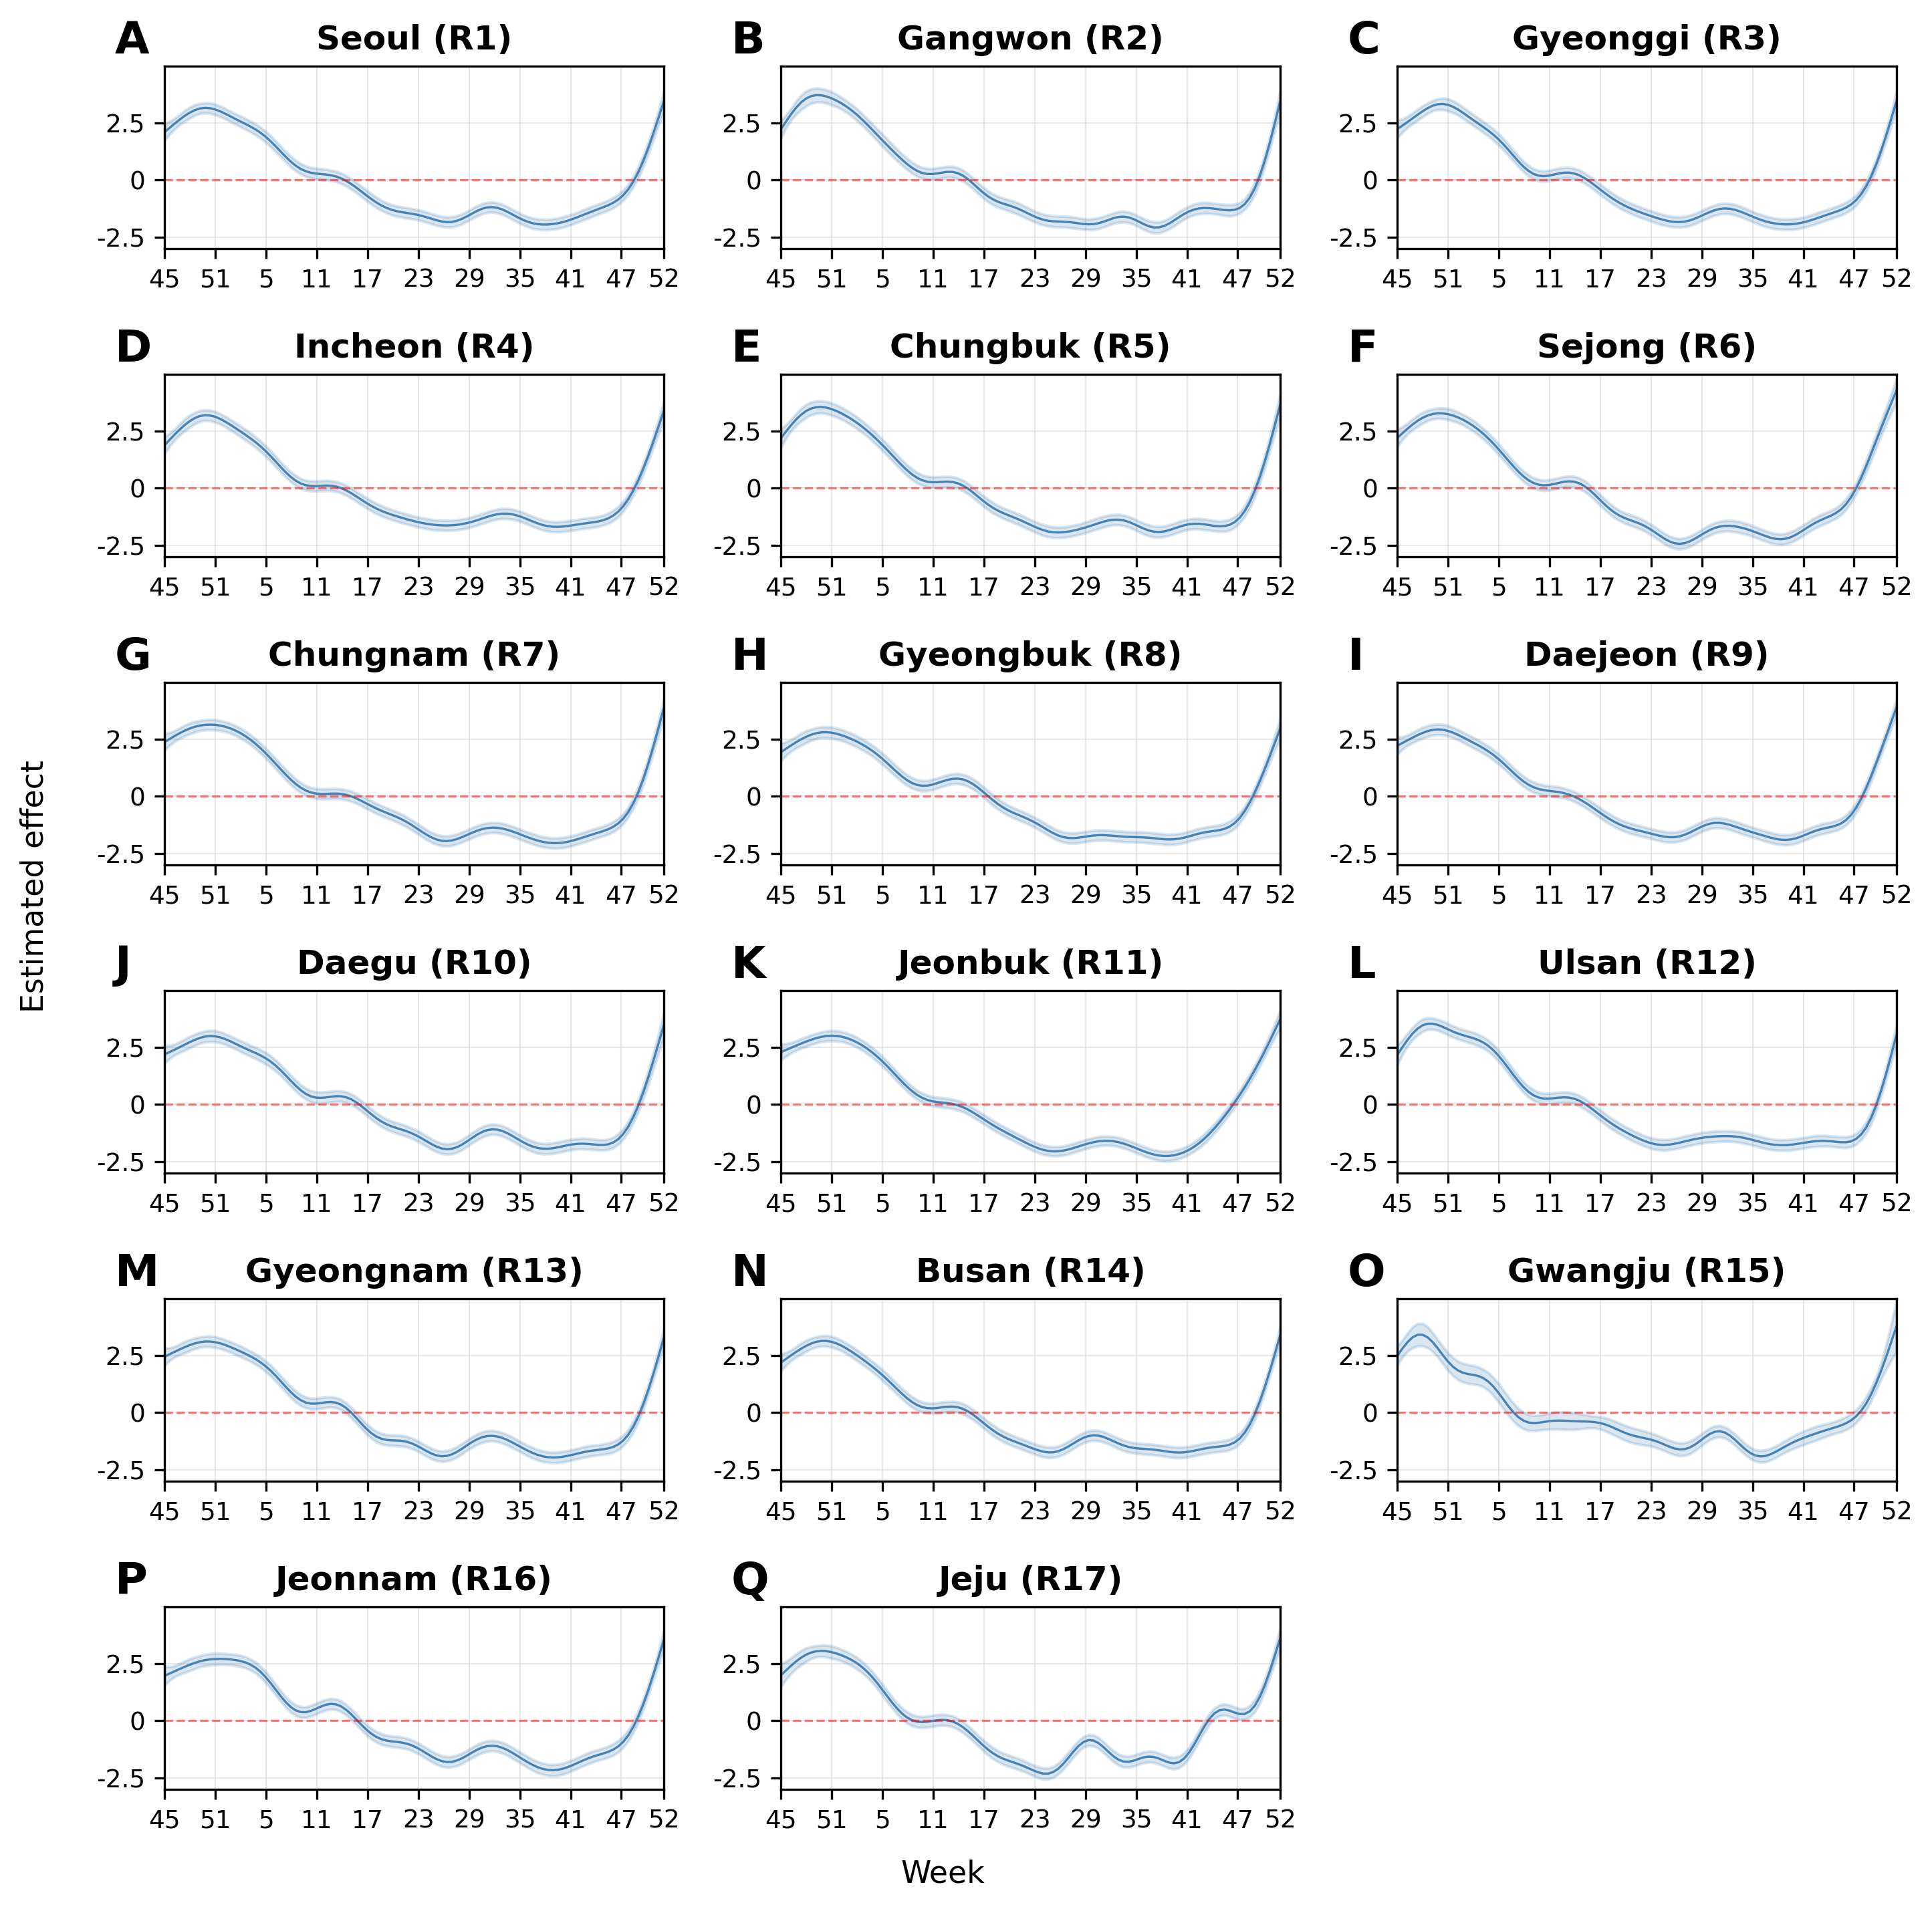

In [9]:
FIG_WIDTH_IN   = 10      
FIG_HEIGHT_IN  = 10      
FIG_DPI        = 300

FS_TITLE       = 12     
FS_AXIS_LABEL  = 11      
FS_TICK        = 9       
FS_PANEL_LABEL = 16      

plt.rcParams.update({
    'font.size': FS_AXIS_LABEL,
    'axes.titlesize': FS_TITLE,
    'axes.labelsize': FS_AXIS_LABEL,
    'xtick.labelsize': FS_TICK,
    'ytick.labelsize': FS_TICK,
})

df = pd.read_csv("../data/Model_results.csv")
df["lower"] = df[".estimate"] - 1.96 * df[".se"]
df["upper"] = df[".estimate"] + 1.96 * df[".se"]

week_map = []
t = 1
for w in range(45, 53):
    week_map.append({"timeindex": t, "year": 2023, "week": w})
    t += 1
for w in range(1, 53):
    week_map.append({"timeindex": t, "year": 2024, "week": w})
    t += 1
week_map = pd.DataFrame(week_map)

tick_interval = 6
tick_df = week_map.iloc[::tick_interval].copy()
if tick_df["timeindex"].iloc[-1] != 60:  
    tick_df = pd.concat(
        [tick_df, week_map[week_map["timeindex"] == 60]],
        ignore_index=True
    )

region_order = [
    "seoul", "gangwon", "gyeonggi", "incheon", "chungbuk", "sejong",
    "chungnam", "gyeongbuk", "daejeon", "daegu", "jeonbuk", "ulsan",
    "gyeongnam", "busan", "gwangju", "jeonnam", "jeju"
]

region_title_map = {
    "seoul": "Seoul (R1)", "gangwon": "Gangwon (R2)", "gyeonggi": "Gyeonggi (R3)",
    "incheon": "Incheon (R4)", "chungbuk": "Chungbuk (R5)", "sejong": "Sejong (R6)",
    "chungnam": "Chungnam (R7)", "gyeongbuk": "Gyeongbuk (R8)", "daejeon": "Daejeon (R9)",
    "daegu": "Daegu (R10)", "jeonbuk": "Jeonbuk (R11)", "ulsan": "Ulsan (R12)",
    "gyeongnam": "Gyeongnam (R13)", "busan": "Busan (R14)", "gwangju": "Gwangju (R15)",
    "jeonnam": "Jeonnam (R16)", "jeju": "Jeju (R17)"
}

region_df = df[df[".smooth"].fillna("").str.startswith("s(timeindex):region")].copy()
region_df["region"] = pd.Categorical(region_df["region"], categories=region_order, ordered=True)
region_df = region_df.sort_values(["region", "timeindex"])

n_regions = len(region_order)
ncol = 3
nrow = math.ceil(n_regions / ncol)

fig, axes = plt.subplots(
    nrow, ncol,
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    dpi=FIG_DPI,
    sharex=False,
    sharey=False
)
axes = np.array(axes).reshape(-1)

for i, region in enumerate(region_order):
    ax = axes[i]
    sub = region_df[region_df["region"] == region].copy()
    sub = sub.sort_values("timeindex")

    ax.fill_between(
        sub["timeindex"].to_numpy(),
        sub["lower"].to_numpy(),
        sub["upper"].to_numpy(),
        color="steelblue",
        alpha=0.2
    )
    ax.plot(
        sub["timeindex"].to_numpy(),
        sub[".estimate"].to_numpy(),
        color="steelblue",
        linewidth=0.8
    )
    ax.axhline(
        0,
        linestyle="--",
        color="red",
        alpha=0.5,
        linewidth=0.8
    )
    ax.set_title(region_title_map[region], fontsize=FS_TITLE, fontweight="bold")
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.set_xlim(1, 60)
    ax.set_xticks(tick_df["timeindex"])
    ax.set_xticklabels(tick_df["week"], fontsize=FS_TICK)
    ax.set_ylim(-3, 5.0)
    ax.set_yticks([-2.5, 0, 2.5])
    ax.set_yticklabels(["-2.5", "0", "2.5"], fontsize=FS_TICK)
    ax.grid(
        True,
        axis="both",
        color="lightgray",
        linewidth=0.5,
        alpha=0.5
    )
    ax.text(
        -0.10,
        1.07,
        string.ascii_uppercase[i],
        transform=ax.transAxes,
        weight="bold",
        fontsize=FS_PANEL_LABEL
    )
    ax.set_axisbelow(True)

for j in range(n_regions, len(axes)):
    axes[j].axis("off")

fig.supxlabel("Week", fontsize=FS_AXIS_LABEL, x=0.5, y=0.05)
fig.supylabel("Estimated effect", fontsize=FS_AXIS_LABEL, x=0.04, y=0.55)

plt.tight_layout(rect=[0.03, 0.03, 1, 1])

# plt.savefig("../figure/Figure2.tiff", dpi=600, bbox_inches="tight")
plt.show()

# Figure 3

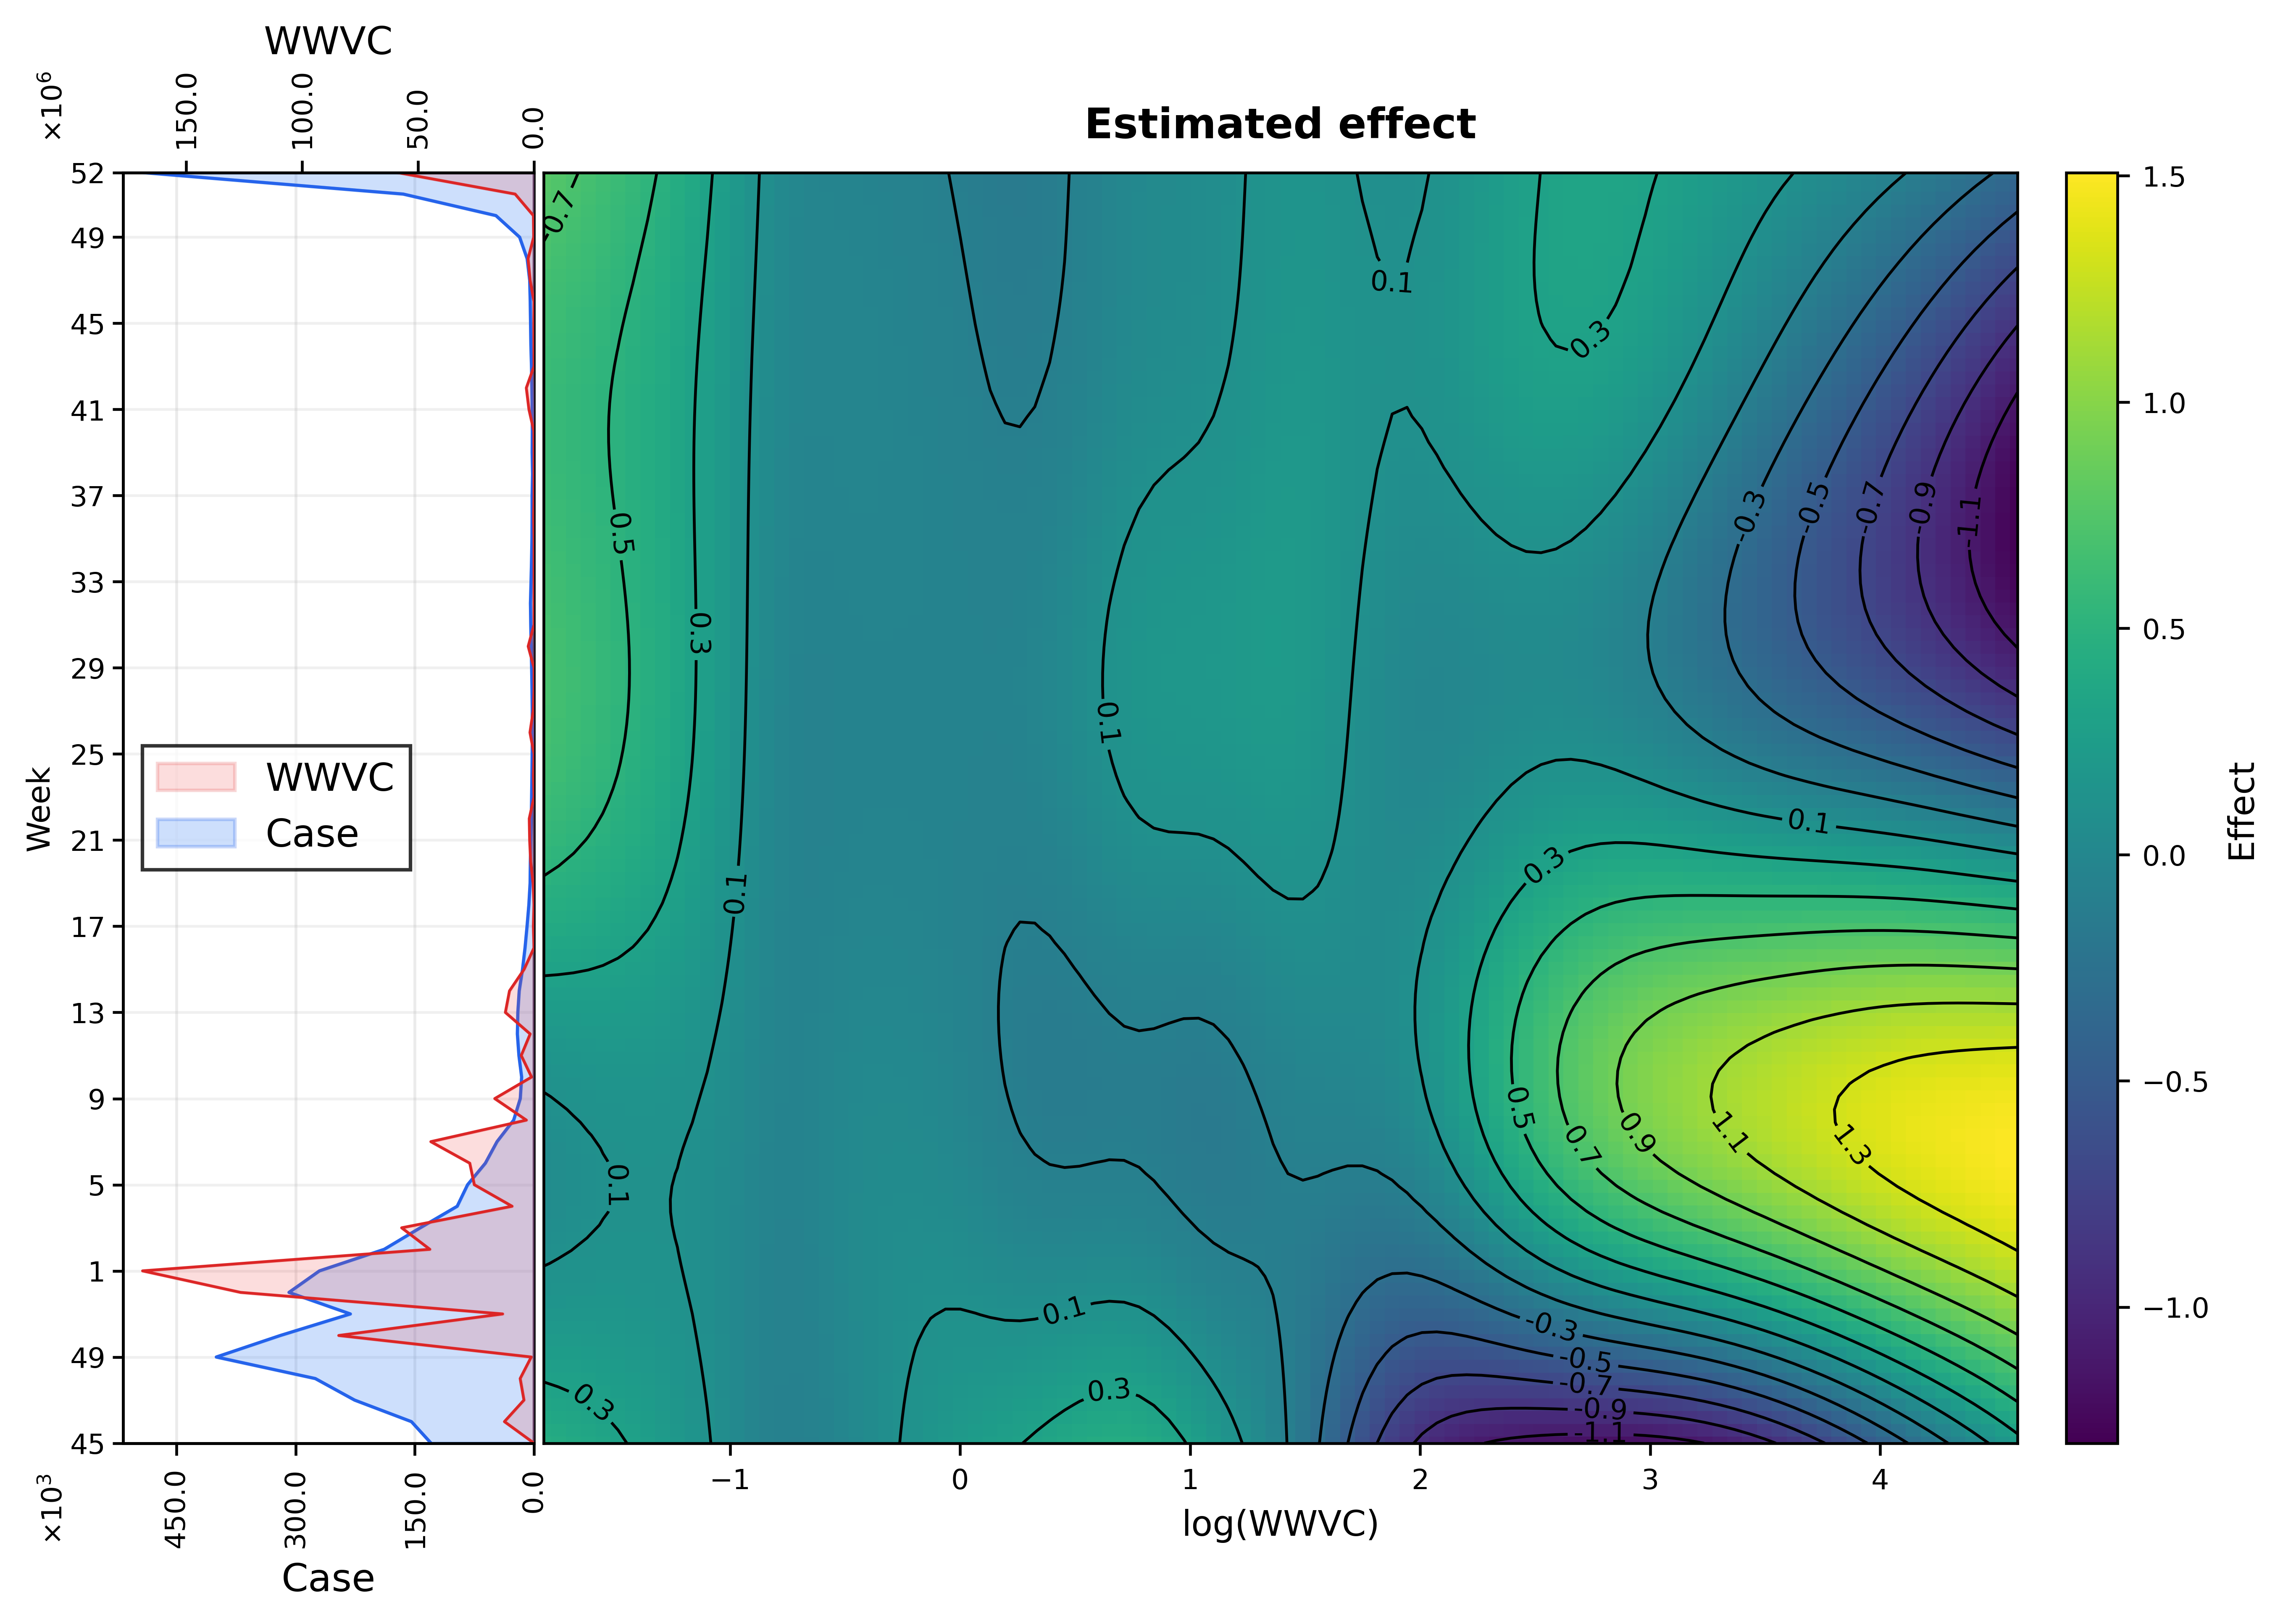

In [ ]:
df = pd.read_csv("../data/Model_results.csv")

smooth_name = "f(log_ircw_z, timeindex)"

d = df[df[".smooth"] == smooth_name].copy()

grid = (
    d.pivot_table(
        index="timeindex",
        columns="log_ircw_z",
        values=".estimate"
    )
    .sort_index()
    .sort_index(axis=1)
)

x_contour = grid.columns.to_numpy()   # x축: log_ircw_z
y_contour = grid.index.to_numpy()     # y축: timeindex
Z = grid.to_numpy()                   # smooth estimate

X, Y = np.meshgrid(x_contour, y_contour)

z_min = np.nanmin(Z)
z_max = np.nanmax(Z)
contour_levels = np.linspace(z_min, z_max, 15)


# =========================================================
# week tick
# =========================================================
data=pd.read_excel("../data/Data.xlsx", index_col=None)
calendar_df = (
    data[["timeindex", "week", "year"]]
    .drop_duplicates()
    .sort_values("timeindex")
    .reset_index(drop=True)
)

week_tick_positions = []
week_tick_labels = []

for idx, row in calendar_df.iterrows():
    xval = row["timeindex"]
    wval = int(row["week"])

    is_first = idx == 0
    is_last = idx == len(calendar_df) - 1

    if is_first or is_last or (wval % 4 == 1):
        week_tick_positions.append(xval)
        week_tick_labels.append(str(wval))


# =========================================================
# left panel data
# =========================================================
left_df = data

left_df = left_df[
    (left_df["timeindex"] >= y_contour.min()) &
    (left_df["timeindex"] <= y_contour.max())
].copy()

y_left = left_df["timeindex"].to_numpy()
case_left = (left_df["case"] / 1e3).to_numpy()   # x10^3
wwvc_left = (left_df["inf"] / 1e6).to_numpy()    # x10^6


# =========================================================
# Figure layout
# =========================================================
fig = plt.figure(figsize=(9.2, 6.3), dpi=600)

outer_gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.45 + 5.2, 0.18],
    wspace=0.05
)

inner_gs = outer_gs[0, 0].subgridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.45, 5.2],
    wspace=0.01
)

ax_left = fig.add_subplot(inner_gs[0, 0])
ax_main = fig.add_subplot(inner_gs[0, 1], sharey=ax_left)
cax = fig.add_subplot(outer_gs[0, 1])


# =========================================================
# left panel: Case and WWVC
# =========================================================
case_fill = ax_left.fill_betweenx(
    y_left,
    0,
    case_left,
    color="#3b82f6",
    alpha=0.25,
    zorder=3
)

ax_left.plot(
    case_left,
    y_left,
    color="#2563eb",
    linewidth=0.9,
    zorder=4
)

ax_left.set_xlim(case_left.max() * 1.05, 0)

ax_left.set_xlabel("Case", fontsize=11)
ax_left.xaxis.set_label_position("bottom")
ax_left.tick_params(axis="x", labelrotation=90, labelsize=8)
ax_left.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax_left.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}"))

ax_left.grid(axis="x", alpha=0.25)
ax_left.grid(axis="y", alpha=0.18)

ax_left.text(
    -0.2, -0.08,
    r"$\times 10^3$",
    transform=ax_left.transAxes,
    ha="left",
    va="bottom",
    rotation=90,
    fontsize=8
)

ax_left_top = ax_left.twiny()

wwvc_fill = ax_left_top.fill_betweenx(
    y_left,
    0,
    wwvc_left,
    color="#ef4444",
    alpha=0.18,
    zorder=1
)

ax_left_top.plot(
    wwvc_left,
    y_left,
    color="#dc2626",
    linewidth=0.8,
    zorder=2
)

ax_left_top.set_xlim(wwvc_left.max() * 1.05, 0)
ax_left_top.set_xlabel("WWVC", fontsize=11)
ax_left_top.xaxis.set_label_position("top")
ax_left_top.tick_params(axis="x", labelrotation=90, labelsize=8)
ax_left_top.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax_left_top.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}"))

ax_left_top.tick_params(
    axis="y",
    left=False,
    labelleft=False,
    right=False,
    labelright=False
)

ax_left_top.patch.set_visible(False)

ax_left_top.text(
    -0.2, 1.08,
    r"$\times 10^6$",
    transform=ax_left_top.transAxes,
    ha="left",
    va="top",
    rotation=90,
    fontsize=8
)


# =========================================================
# legend
# =========================================================
legend_handles = [
    Patch(facecolor="#ef4444", edgecolor="#dc2626", alpha=0.18, label="WWVC"),
    Patch(facecolor="#3b82f6", edgecolor="#2563eb", alpha=0.25, label="Case"),
]

leg = ax_left.legend(
    handles=legend_handles,
    loc="center left",
    fontsize=11,
    frameon=True,
    fancybox=False,
    edgecolor="black"
)

# =========================================================
# right contour plot
# =========================================================
mesh = ax_main.pcolormesh(
    X,
    Y,
    Z,
    shading="auto",
    cmap="viridis",
    vmin=z_min,
    vmax=z_max
)

cs = ax_main.contour(
    X,
    Y,
    Z,
    levels=contour_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid"
)

label_levels = np.delete(contour_levels, [6])

texts = ax_main.clabel(
    cs,
    levels=label_levels,
    inline=True,
    fontsize=8,
    fmt="%.1f"
)

ax_main.set_xlabel("log(WWVC)", fontsize=10)

ax_main.set_xlim(x_contour.min(), x_contour.max())
ax_main.set_ylim(y_contour.min(), y_contour.max())

ax_main.tick_params(axis="x", labelsize=8)

ax_main.set_title(
    "Estimated effect",
    pad=10,
    fontweight="bold",
    fontsize=12
)

# =========================================================
# Colorbar
# =========================================================
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Effect", fontsize=10)
cbar.ax.tick_params(labelsize=8)

# =========================================================
# y-axis
# =========================================================

week_ticks = []
week_labels = []

for pos, lab in zip(week_tick_positions, week_tick_labels):
    if y_contour.min() <= pos <= y_contour.max():
        week_ticks.append(pos)
        week_labels.append(lab)

ax_left.spines["right"].set_visible(True)
ax_left_top.spines["right"].set_visible(False)

ax_main.spines["left"].set_visible(True)

ax_main.tick_params(
    axis="y",
    left=False,
    labelleft=False,
    right=False,
    labelright=False
)

ax_left.set_yticks(week_ticks)
ax_left.set_yticklabels(
    week_labels,
    rotation=0,      
    fontsize=8
)

ax_left.tick_params(
    axis="y",
    left=True,
    labelleft=True,
    right=False,
    labelright=False,
    length=3,
    pad=2
)

ax_left.yaxis.set_ticks_position("left")
ax_left.yaxis.set_label_position("left")
ax_left.set_ylabel("Week", fontsize=9)


fig.subplots_adjust(
    left=0.08,
    right=0.94,
    bottom=0.10,
    top=0.90
)

# plt.savefig("../figure/Figure3.tiff", dpi=600, bbox_inches="tight")
plt.show()